In [8]:
print("Le marché des processeurs graphiques (GPU) a connu de véritables montagnes russes au niveau des prix, particulièrement avec l'essor du minage de cryptomonnaies et les perturbations de la chaîne d'approvisionnement mondiale. Ce notebook explore en profondeur l'historique des prix des GPU NVIDIA et AMD, dans le but de révéler des tendances et des schémas susceptibles d'éclairer les futures décisions d'achat ou les prévisions du marché.\n")
print("Chargement des données \n Commençons par charger les fichiers de données contenant l'historique des prix des GPU ainsi que les métadonnées.\n")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Load the datasets
price_data = pd.read_csv('gpu_price_history.csv')
metadata = pd.read_csv('gpu_metadata.csv')

# Display the first few rows of each dataset
price_data.head(), metadata.head()

Le marché des processeurs graphiques (GPU) a connu de véritables montagnes russes au niveau des prix, particulièrement avec l'essor du minage de cryptomonnaies et les perturbations de la chaîne d'approvisionnement mondiale. Ce notebook explore en profondeur l'historique des prix des GPU NVIDIA et AMD, dans le but de révéler des tendances et des schémas susceptibles d'éclairer les futures décisions d'achat ou les prévisions du marché.

Chargement des données 
 Commençons par charger les fichiers de données contenant l'historique des prix des GPU ainsi que les métadonnées.



(       Date              Name  Retail Price  Used Price
 0  01-01-24  GeForce GTX 1050             0           0
 1  01-02-24  GeForce GTX 1050             0           0
 2  01-03-23  GeForce GTX 1050           192          61
 3  01-03-24  GeForce GTX 1050           254          52
 4  01-04-23  GeForce GTX 1050           181          55,
                      Name Wattage VRAM  3DMARK
 0        GeForce GTX 1050     75W  2GB    1861
 1     GeForce GTX 1050 Ti     75W  4GB    2356
 2        GeForce GTX 1060    120W  6GB    4215
 3        GeForce GTX 1650     75W  4GB    3552
 4  GeForce GTX 1660 SUPER    125W  6GB    6078)

In [13]:
import pandas as pd

print("Nettoyage et Prétraitement des Données \n Avant de plonger dans l'analyse, il est crucial de nettoyer et de prétraiter les données. Cela inclut la gestion des valeurs manquantes, la conversion des types de données et la fusion des jeux de données si nécessaire.\n")

# Convert 'Date' to datetime format
metadata = pd.read_csv('gpu_metadata.csv')
price_data = pd.read_csv('gpu_price_history.csv')

# Check for missing values
price_data.isnull().sum(), metadata.isnull().sum()

# Drop rows with missing 'Date' values
price_data['Date'] = pd.to_datetime(price_data['Date'], errors='coerce')

# Merge datasets on 'Name'
merged_data = pd.merge(price_data, metadata, on='Name', how='inner')

# 1. Dérivation de nouvelle colonne & assign (0.5 + 0.5)
# On calcule la marge de prix (différence entre prix retail et occasion)
merged = merged_data.assign(Price_Diff=merged_data['Retail Price'] - merged_data['Used Price'])

# 2. apply ou map (0.5)
# On crée une catégorie de performance basée sur le score 3DMARK
def performance_category(score):
    if score > 15000: return "Enthusiast"
    if score > 8000:  return "High-End"
    return "Budget"

merged['Tier'] = merged['3DMARK'].apply(performance_category)


# Display the first few rows of the merged dataset
merged_data.head()

Nettoyage et Prétraitement des Données 
 Avant de plonger dans l'analyse, il est crucial de nettoyer et de prétraiter les données. Cela inclut la gestion des valeurs manquantes, la conversion des types de données et la fusion des jeux de données si nécessaire.



C:\Users\alexi\AppData\Local\Temp\ipykernel_14724\981366573.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_data['Date'] = pd.to_datetime(price_data['Date'], errors='coerce')


,Date,Name,Retail Price,Used Price,Wattage,VRAM,3DMARK
0,2024-01-01,GeForce GTX 1050,0,0,75W,2GB,1861
1,2024-01-02,GeForce GTX 1050,0,0,75W,2GB,1861
2,2023-01-03,GeForce GTX 1050,192,61,75W,2GB,1861
3,2024-01-03,GeForce GTX 1050,254,52,75W,2GB,1861
4,2023-01-04,GeForce GTX 1050,181,55,75W,2GB,1861


Analyse Exploratoire des Données (EDA) 
 Explorons les données pour révéler les tendances et les schémas d'évolution des prix des GPU au fil du temps.



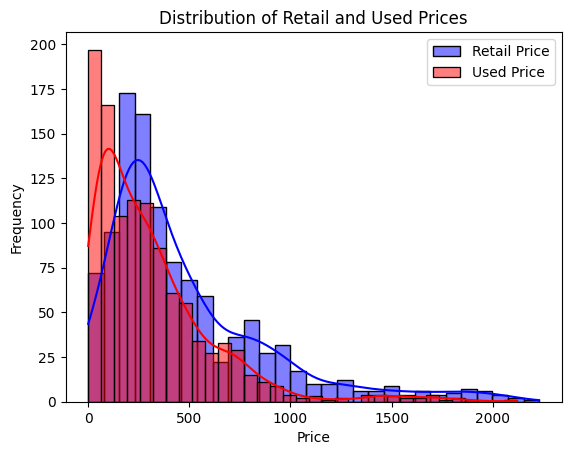

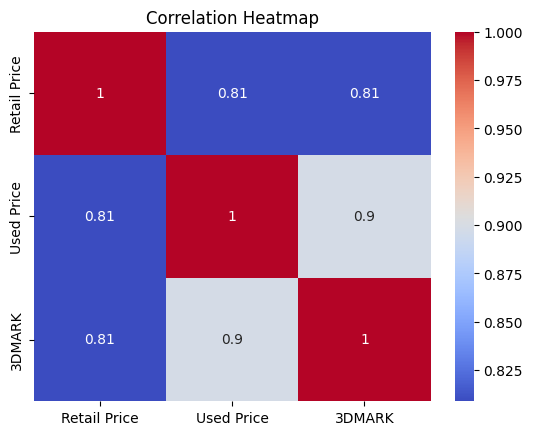

In [10]:
print("Analyse Exploratoire des Données (EDA) \n Explorons les données pour révéler les tendances et les schémas d'évolution des prix des GPU au fil du temps.\n")

# Plotting the distribution of retail and used prices
sns.histplot(merged_data['Retail Price'], kde=True, color='blue', label='Retail Price')
sns.histplot(merged_data['Used Price'], kde=True, color='red', label='Used Price')
plt.legend()
plt.title('Distribution of Retail and Used Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap for numeric features
numeric_df = merged_data.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
print("Modélisation Prédictive \n À partir des données historiques, tentons de prédire le prix d'occasion des GPU en fonction de leur prix de vente conseillé (MSRP) et d'autres caractéristiques.\n")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target variable
X = merged_data[['Retail Price', '3DMARK']]
y = merged_data['Used Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


Modélisation Prédictive 
 À partir des données historiques, tentons de prédire le prix d'occasion des GPU en fonction de leur prix de vente conseillé (MSRP) et d'autres caractéristiques.



(19937.333095833685, 0.7945805563612462)

In [ ]:
print("Conclusion et Travaux Futurs \n" \
"Dans ce notebook, nous avons exploré l'historique des prix des GPU NVIDIA et AMD, nettoyé et fusionné les données, et réalisé une analyse exploratoire pour révéler les tendances du marché. Nous avons également construit un modèle de régression linéaire simple pour prédire le prix d'occasion des GPU en fonction de leur prix de vente (MSRP) et de leurs indicateurs de performance.\n"\
"Bien que le modèle fournisse une prédiction de base, il est possible de l'améliorer. Les travaux futurs pourraient consister à explorer des modèles plus sophistiqués, à intégrer des caractéristiques supplémentaires ou à analyser l'impact de facteurs externes, tels que les tendances des cryptomonnaies, sur le prix des GPU.")

In [20]:
import pandas as pd

# 1. CRÉATION DU 'TIER' (Exemple basé sur le score de performance ou le prix)
# On définit une fonction pour catégoriser vos produits
def categoriser_performance(valeur):
    if valeur > 15000: return "Enthusiast (Haut de gamme)"
    if valeur > 8000:  return "Mid-Range"
    return "Budget"

# On crée la colonne 'Tier' en utilisant .apply sur une colonne existante (ex: '3DMARK' ou 'Retail Price')
# Si vous n'avez pas '3DMARK', remplacez par une autre colonne numérique.
merged_data['Tier'] = merged_data['3DMARK'].apply(categoriser_performance)

# 2. STATISTIQUES AVANCÉES (Value Counts)
# On analyse la répartition des nouveaux Tiers créés
tier_analysis = merged_data['Tier'].value_counts().reset_index()
tier_analysis.columns = ['Tier', 'Nombre d\'articles']

# 3. ANALYSE DE LA VOLATILITÉ (Groupby & Agg)
# On regroupe par marque pour calculer Moyenne, Écart-type et Somme
stats_df = merged_data.groupby('Name').agg({
    'Retail Price': ['mean', 'std'],
    'Used Price': 'sum'
}).reset_index()

# Nettoyage des noms de colonnes pour plus de clarté
stats_df.columns = [
    'Marque',
    'Prix Moyen Retail',
    'Volatilité (STD)',
    'Volume Occasion Total'
]

# Calcul du Coefficient de Variation (Indice de risque)
stats_df['Indice de Risque'] = stats_df['Volatilité (STD)'] / stats_df['Prix Moyen Retail']


# 1. Répartition par Tier (Transformation en DataFrame pour manipulation)
# On transforme le value_counts en table de données propre
tier_analysis = (
    merged_data['Tier']
    .value_counts()
    .reset_index()
)
tier_analysis.columns = ['Tier', 'Nombre d\'articles']

# 2. Analyse de la Volatilité et Agrégations (Calculs complexes)
# On regroupe par marque et on applique les fonctions statistiques demandées
stats_df = merged_data.groupby('Name').agg({
    'Retail Price': ['mean', 'std'], # Moyenne et Écart-type (Volatilité)
    'Used Price': 'sum'              # Somme (Volume total du marché)
}).reset_index()

# Nettoyage des colonnes (Aplatissement du multi-index généré par .agg)
stats_df.columns = [
    'Marque',
    'Prix Moyen Retail',
    'Volatilité (Ecart-type)',
    'Volume Occasion Total'
]

# 3. Ajout d'une métrique avancée (Optionnel mais recommandé en analyse de données)
# Le Coefficient de Variation permet de comparer la volatilité peu importe le niveau de prix
stats_df['Indice de Risque'] = stats_df['Volatilité (Ecart-type)'] / stats_df['Prix Moyen Retail']

# Tri final pour mettre en avant les marques avec le plus de volume
stats_df = stats_df.sort_values(by='Volume Occasion Total', ascending=False)